<a href="https://colab.research.google.com/github/YoshnaM/6CS012-Artificial-Intelligence-and-Machine-Learning/blob/main/2406791_Yoshna_Maharjan_Code_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification with Convolutional Neural Network

# Part A: Designing and Analyzing Convolutional Neural Networks from Scratch

## Data Understanding, Analysis, Visualization and Cleaning

### Importing Libraries

In [ ]:
import os
import shutil
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import warnings
warnings.filterwarnings("ignore")

### Load the Dataset

In [ ]:
input_dir = "/kaggle/input/datasets/yoshnamaharjan/sign-language-detection/Sign Language Detection"
work_dir = "/kaggle/working/dataset_clean"

if not os.path.exists(work_dir):
    shutil.copytree(input_dir, work_dir)

original_train_dir = f"{work_dir}/Train"
original_test_dir  = f"{work_dir}/Test"

print(original_train_dir)
print(original_test_dir)

/kaggle/working/dataset_clean/Train
/kaggle/working/dataset_clean/Test


### Dataset Description

In [ ]:
# Explore class structure
classes = sorted(os.listdir(original_train_dir))
num_classes = len(classes)

print(f"Number of classes: {num_classes}")
print(f"Classes: {classes}")

Number of classes: 38
Classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '4', '5', '6', '7', '8', '9']


**What does the dataset represent?**

This dataset is a "Bengali Sign Language Detection" dataset. It contains hand gesture images representing 38 distinct sign language symbols (digits 0 - 37, corresponding to the Bengali sign gestures). Each class folder contains JPEG/PNG images of hand signs captured under varying conditions.

### Class Distribution

In [ ]:
# Count images per class
class_counts = {}
total_images = 0

for cls in classes:
    cls_path = os.path.join(original_train_dir, cls)
    imgs = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(imgs)
    total_images += len(imgs)

print(f"Total images in Train: {total_images}")

Total images in Train: 11058


**How many total images are in the dataset?**

There are 11,058 images in the original training set.

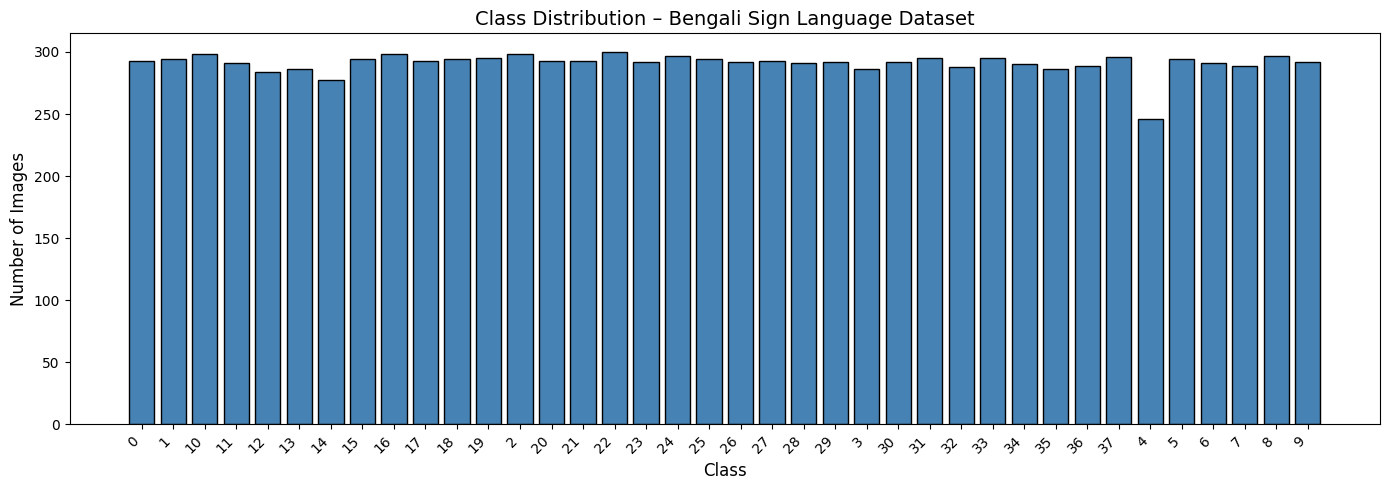

In [ ]:
# Bar chart of class distribution
plt.figure(figsize=(14, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
plt.title('Class Distribution – Bengali Sign Language Dataset', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**What is the distribution of images across different classes?**

The barchart above shows the number of images per class in the training set. The distribution is relatively balanced, with most classes containing approximately 280-300 images each. This balance is important because it means the model is unlikely to develop a bias towards any particular class due to data imbalance.

### Check for Corrupted Images

In [ ]:
corrupted = []

clean_base = "/kaggle/working/clean_train"

if not os.path.exists(clean_base):
    shutil.copytree(original_train_dir, clean_base)

for cls in classes:
    cls_path = os.path.join(clean_base, cls)

    for img_file in os.listdir(cls_path):
        if not img_file.lower().endswith(('.jpg','.jpeg','.png')):
            continue

        img_path = os.path.join(cls_path, img_file)

        try:
            with Image.open(img_path) as img:
                img.verify()
        except:
            corrupted.append(img_path)

print("Corrupted images:", len(corrupted))

# 3. Delete safely from copied dataset
for path in corrupted:
    try:
        os.remove(path)
    except:
        pass

print(f"Deleted {len(corrupted)} corrupted images from cleaned dataset.")
original_train_dir = clean_base

Corrupted images: 266
Deleted 266 corrupted images from cleaned dataset.


### Train / Validation / Test Split

In [ ]:
base_dir = "/kaggle/working/split_dataset"

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

TRAIN_RATIO = 0.7
VAL_RATIO = 0.2

random.seed(42)

if not os.path.exists(train_dir):

    for d in [train_dir, val_dir, test_dir]:
        os.makedirs(d, exist_ok=True)

    for cls in classes:
        cls_src = os.path.join(original_train_dir, cls)
        images = [f for f in os.listdir(cls_src) if f.lower().endswith(('.jpg','.png','.jpeg'))]
        random.shuffle(images)

        n = len(images)
        n_train = int(n * TRAIN_RATIO)
        n_val = int(n * VAL_RATIO)

        splits = {
            train_dir: images[:n_train],
            val_dir: images[n_train:n_train+n_val],
            test_dir: images[n_train+n_val:]
        }

        for dest, files in splits.items():
            dest_cls = os.path.join(dest, cls)
            os.makedirs(dest_cls, exist_ok=True)

            for f in files:
                shutil.copy(os.path.join(cls_src, f), os.path.join(dest_cls, f))

print("Split ready.")

# Count split sizes
for split_name, split_path in [("Train", train_dir), ("Validation", val_dir), ("Test", test_dir)]:
    count = sum(len(os.listdir(os.path.join(split_path, c))) for c in os.listdir(split_path))
    print(f"{split_name}: {count} images")

Split ready.
Train: 7536 images
Validation: 2144 images
Test: 1112 images


**How is the dataset split into training and validation sets? Justify your choice.**

The cleaned training data is split into three subsets using a stratified per-class shuffle: 70% Train, 20% Validation, 10% Test. A 70% training set provides sufficient data for the model to learn meaningful features. A 20% validation set is large enough to produce stable loss and accuracy estimates across 38 classes, enabling reliable early stopping and learning rate scheduling decisions. The original provided Test folder contained only 3 images, which was insufficient for reliable evaluation. Therefore, a dedicated 10% test set was held out entirely from the cleaned dataset and used only for finla evaluation to ensure an unbiased estimate of real-world performance. Thus, I think this justifies the choice of 70/20/10 split.

### Sample Images from Each Class

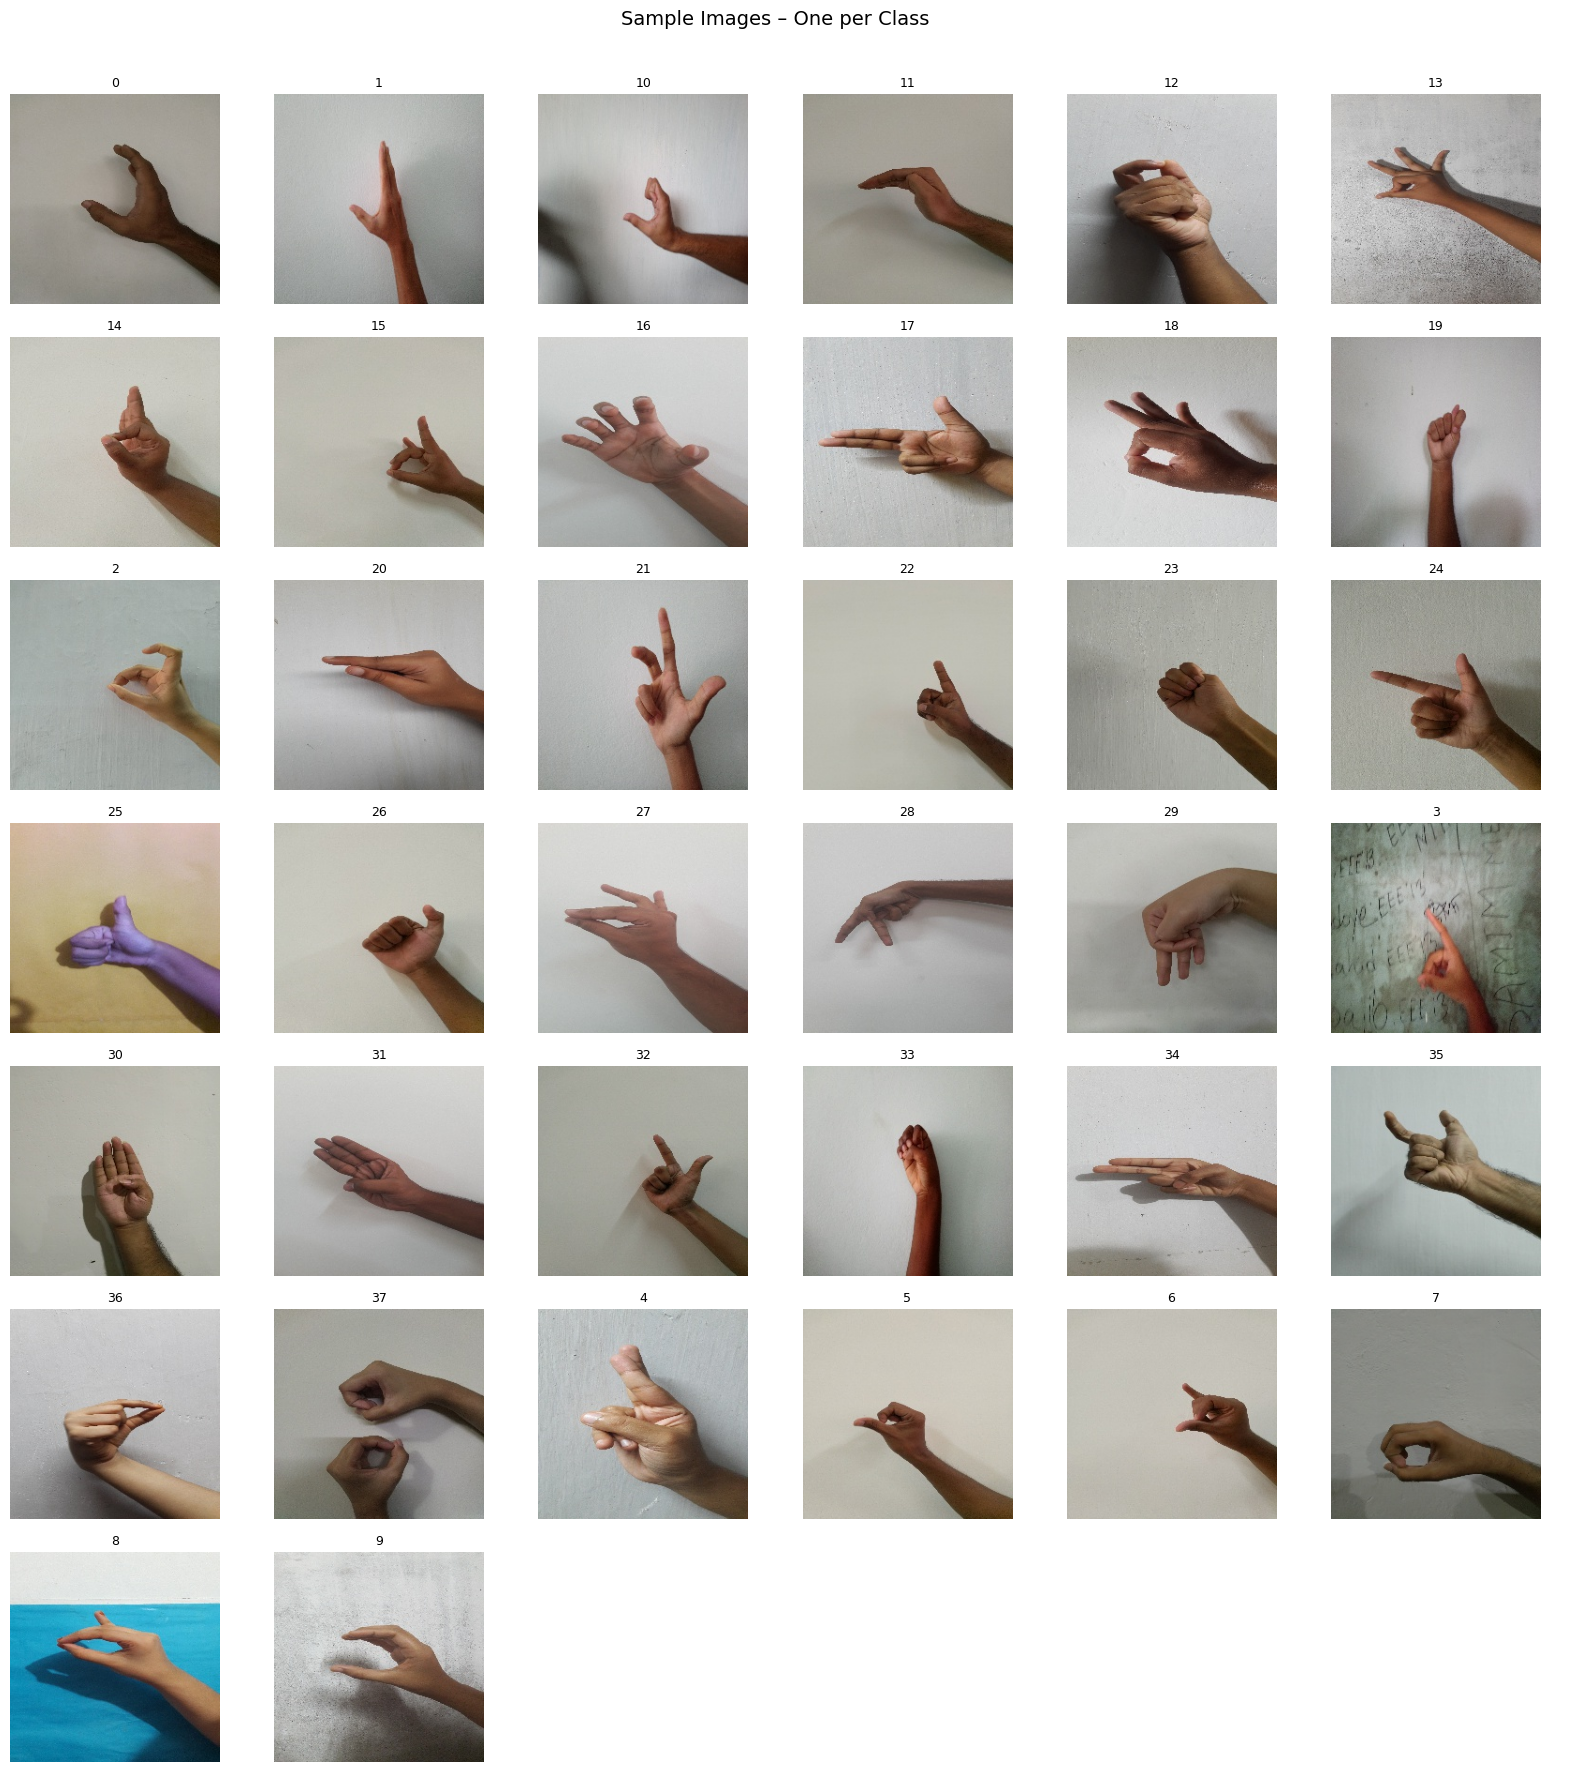

In [ ]:
n_cols = 6
n_rows = int(np.ceil(num_classes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2.5))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    sample_img = random.choice(os.listdir(cls_path))
    img = mpimg.imread(os.path.join(cls_path, sample_img))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images – One per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Preprocessing and Data Augmentation

The Pixel values were normalized to [0, 1] by dividing by 255.

In [ ]:
IMG_SIZE  = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.12,
    brightness_range=[0.75, 1.25],
    shear_range=6,
    horizontal_flip=False,
    fill_mode='nearest',
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

In [ ]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
print(f"Number of classes detected: {NUM_CLASSES}")

Found 7536 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
Found 1112 images belonging to 38 classes.
Number of classes detected: 38


**What preprocessing techniques (e.g., resizing, normalization) were applied?**

All the pixel values are normalized to the [0,1] range by dividing by 255. This ensures faster and more stable gradient descent by keeping inouts in a consistent scale. All images are resized to 224x224 pixels to provide a uniform input shape. A batch size of 32 is used, which balances memory efficiency and gradient stability.

**What data generators, if any, were used for preprocessing and augmentation?**

Keras "ImageDataGenerator" was used for preprocessing and augmentation, where the training generator applied rotation, width/height shift, zoom, brightness range, and shear with nearest fill mode to simulate variations in hand position, scale, lighting, and perspective, while horizontal flip was disabled to avoid creating invalid sign language samples. Validation and test generators used only rescaling to ensure realistic and unbiased evaluation.


### Visualizing Augmented Images

**If data augmentation was applied, provide visualizations of sample augmented images.**

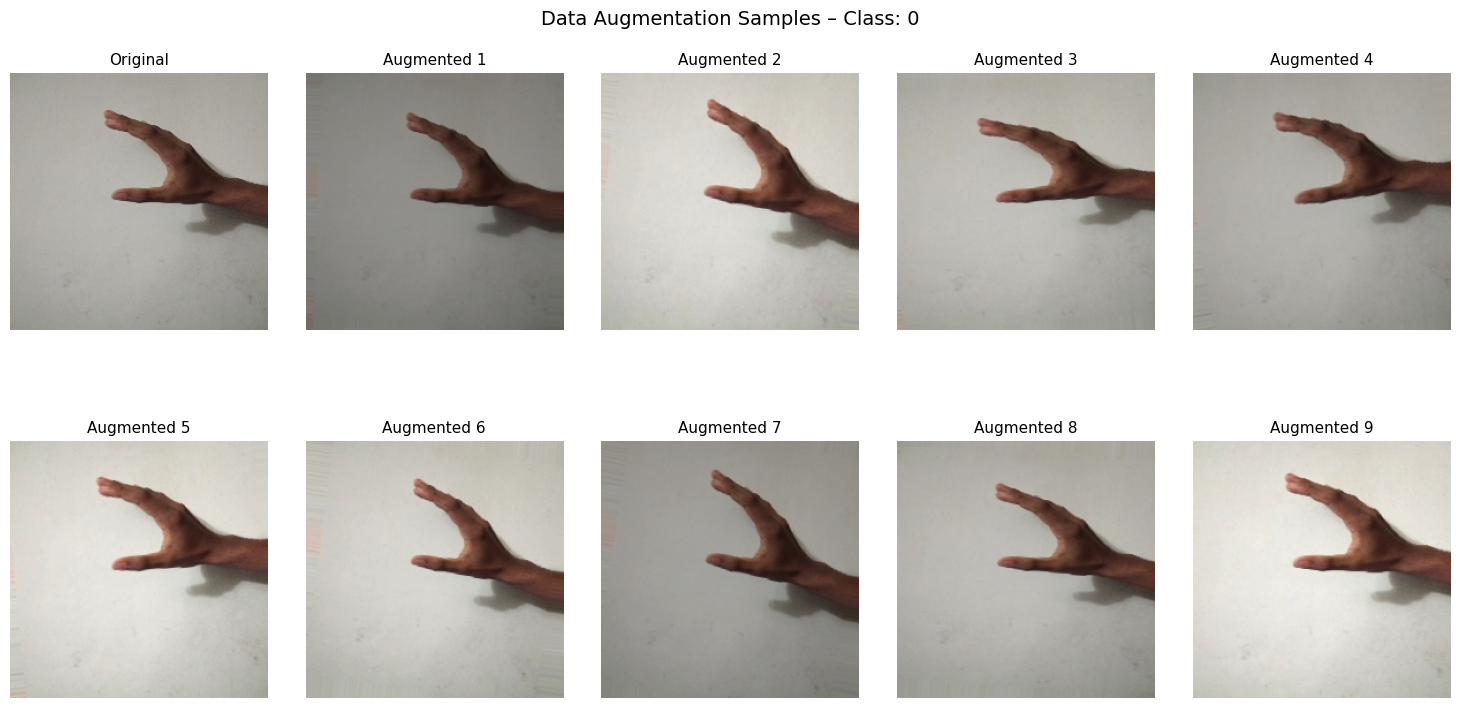

In [ ]:
sample_cls = classes[0]
sample_img_path = os.path.join(
    train_dir,
    sample_cls,
    os.listdir(os.path.join(train_dir, sample_cls))[0]
)

original = Image.open(sample_img_path).resize(IMG_SIZE)
orig_arr = np.array(original) / 255.0

# Generator for augmentations (using training size)
vis_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    brightness_range=[0.7, 1.3],
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest',
)

img_expanded = np.array(Image.open(sample_img_path).resize(IMG_SIZE)).reshape((1,) + IMG_SIZE + (3,))
aug_iter = vis_datagen.flow(
    img_expanded,
    batch_size=1,
    seed=42
)

# Plot with better spacing
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()

# Original
axes[0].imshow(orig_arr)
axes[0].set_title('Original', fontsize=11)
axes[0].axis('off')

# Augmented images
for idx in range(1, 10):
    aug_img = next(aug_iter)[0]
    axes[idx].imshow(aug_img)
    axes[idx].set_title(f'Augmented {idx}', fontsize=11)
    axes[idx].axis('off')

plt.suptitle(f'Data Augmentation Samples – Class: {sample_cls}',
             fontsize=14, y=0.95)

plt.subplots_adjust(
    left=0.05,
    right=0.95,
    top=0.88,
    bottom=0.08,
    hspace=0.35,
    wspace=0.15
)

plt.show()

## Design, Train, and Evaluate a Baseline Model:

### Baseline Model Architecture

In [ ]:
def build_baseline_model(num_classes, input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='Baseline_CNN')

    return model

In [ ]:
baseline_model = build_baseline_model(NUM_CLASSES)

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,827,238 (98.52 MB)

 Trainable params: 25,827,238 (98.52 MB)

 Non-trainable params: 0 (0.00 B)

### Training Baseline Model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='baseline_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

EPOCHS = 30

start_time = time.time()

In [ ]:
baseline_history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

baseline_train_time = time.time() - start_time
print(f"\nBaseline model training time: {baseline_train_time:.1f} seconds")

Epoch 1/30


I0000 00:00:1778143977.817297     167 service.cc:152] XLA service 0x7fa73c011b80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778143977.817333     167 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778143977.817336     167 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778143978.407293     167 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/236 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.0312 - loss: 4.7074

I0000 00:00:1778143984.668455     167 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.0285 - loss: 3.7833
Epoch 1: val_loss improved from inf to 3.63712, saving model to baseline_best_model.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 103s 399ms/step - accuracy: 0.0285 - loss: 3.7829 - val_accuracy: 0.0280 - val_loss: 3.6371 - learning_rate: 0.0010
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.0606 - loss: 3.5383
Epoch 2: val_loss improved from 3.63712 to 3.10070, saving model to baseline_best_model.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 91s 384ms/step - accuracy: 0.0607 - loss: 3.5378 - val_accuracy: 0.1483 - val_loss: 3.1007 - learning_rate: 0.0010
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.1561 - loss: 3.0775
Epoch 3: val_loss improved from 3.10070 to 2.51563, saving model to baseline_best_model.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 90s 380ms/step - accuracy: 0.1562 - loss: 3.0771 - val_accuracy: 0.2738 - val_loss: 2.5156 - learning_rate: 0.0010
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━

### Training vs Validation Loss and Accuracy Curves

In [ ]:
def plot_history(history, title='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{title} – Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[1].set_title(f'{title} – Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

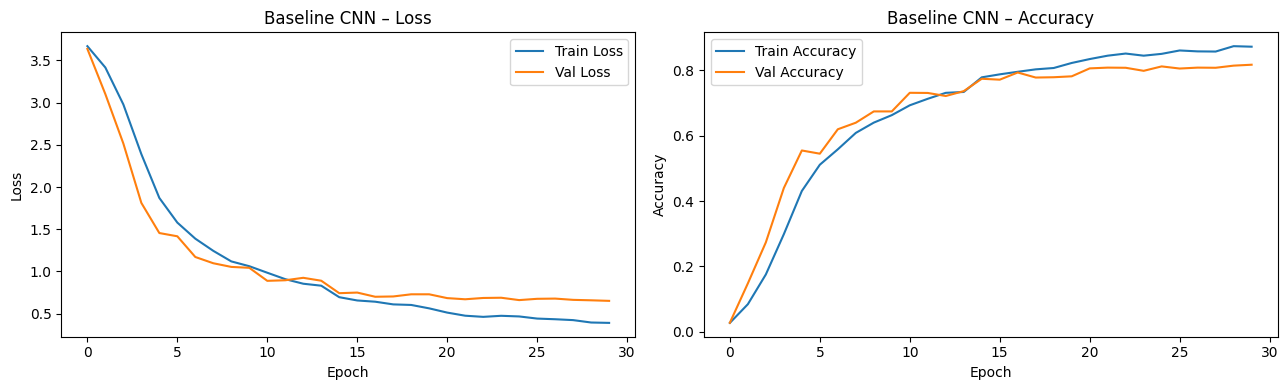

In [ ]:
plot_history(
    baseline_history,
    title='Baseline CNN'
)

### Evaluating Baseline Model

In [ ]:
def evaluate_model(model, generator, model_name='Model'):
    generator.reset()
    loss, acc = model.evaluate(generator, verbose=0)
    print(f"\n{model_name} – Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")

    generator.reset()
    y_pred_probs = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes
    class_labels = list(generator.class_indices.keys())

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    fig, ax = plt.subplots(figsize=(12, 10))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} – Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return y_pred, y_true, acc


Baseline CNN – Test Loss: 0.5535 | Test Accuracy: 0.8381

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.96      0.83      0.89        30
          10       1.00      0.93      0.97        30
          11       0.96      0.87      0.91        30
          12       0.83      0.83      0.83        29
          13       0.75      0.83      0.79        29
          14       0.78      0.78      0.78        27
          15       0.79      0.63      0.70        30
          16       0.87      0.87      0.87        30
          17       0.90      0.93      0.92        29
          18       0.67      0.73      0.70        30
          19       0.81      0.70      0.75        30
           2       0.90      0.87      0.88        30
          20       0.90      0.90      0.90        29
          21       0.82      0.97      0.89        29
          22       0.76      0.83      0.79        30

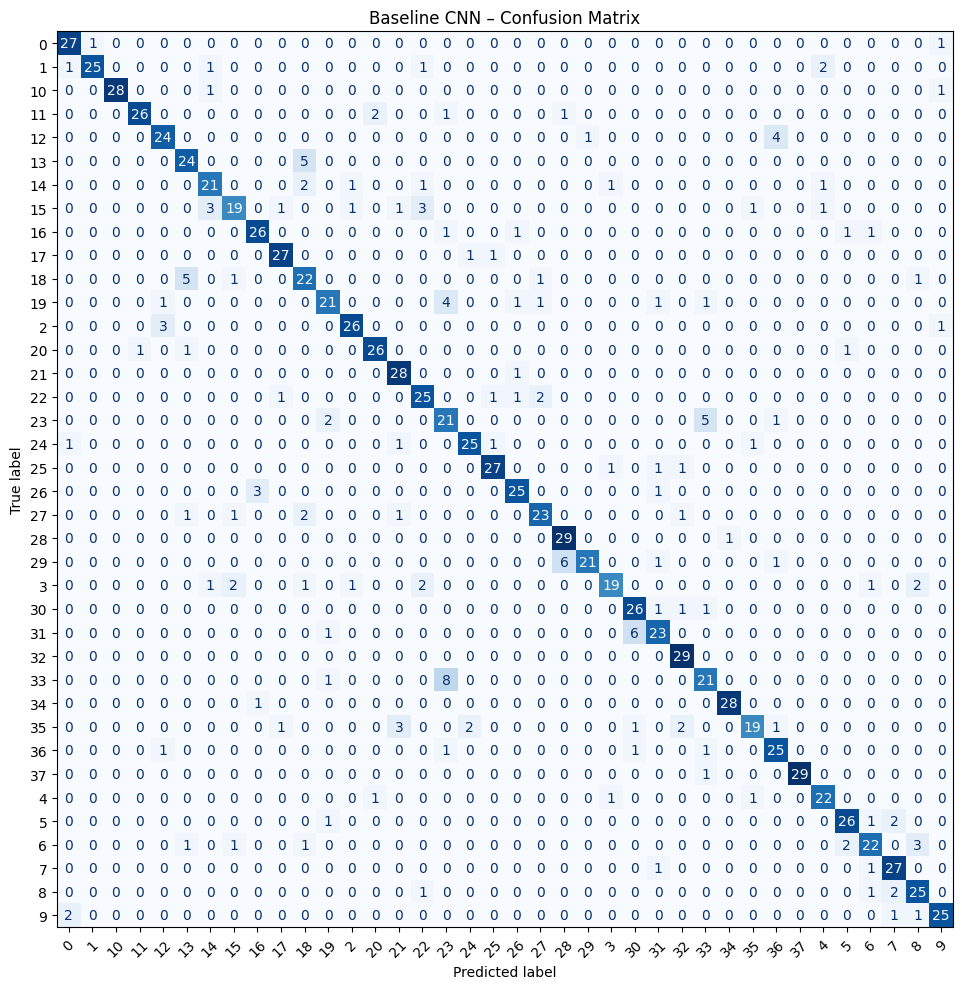

In [ ]:
baseline_pred, baseline_true, baseline_acc = evaluate_model(
    baseline_model,
    test_gen,
    'Baseline CNN'
)

### Inference on Sample Test Images

In [ ]:
def show_predictions(model, generator, n=10):
    class_names = list(generator.class_indices.keys())
    generator.reset()
    images, labels = next(generator)
    preds = model.predict(images[:n], verbose=0)

    fig, axes = plt.subplots(2, 5, figsize=(16, 8))
    axes = axes.flatten()
    for i in range(n):
        axes[i].imshow(images[i])
        true_label  = class_names[np.argmax(labels[i])]
        pred_label  = class_names[np.argmax(preds[i])]
        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title(f'T: {true_label}\nP: {pred_label}', color=color, fontsize=8)
        axes[i].axis('off')
    plt.suptitle(f'{model.name} – Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14, y=0.95)
    plt.subplots_adjust(
        left=0.05,
        right=0.95,
        top=0.88,
        bottom=0.08,
        hspace=0.35,
        wspace=0.15
    )
    plt.show()

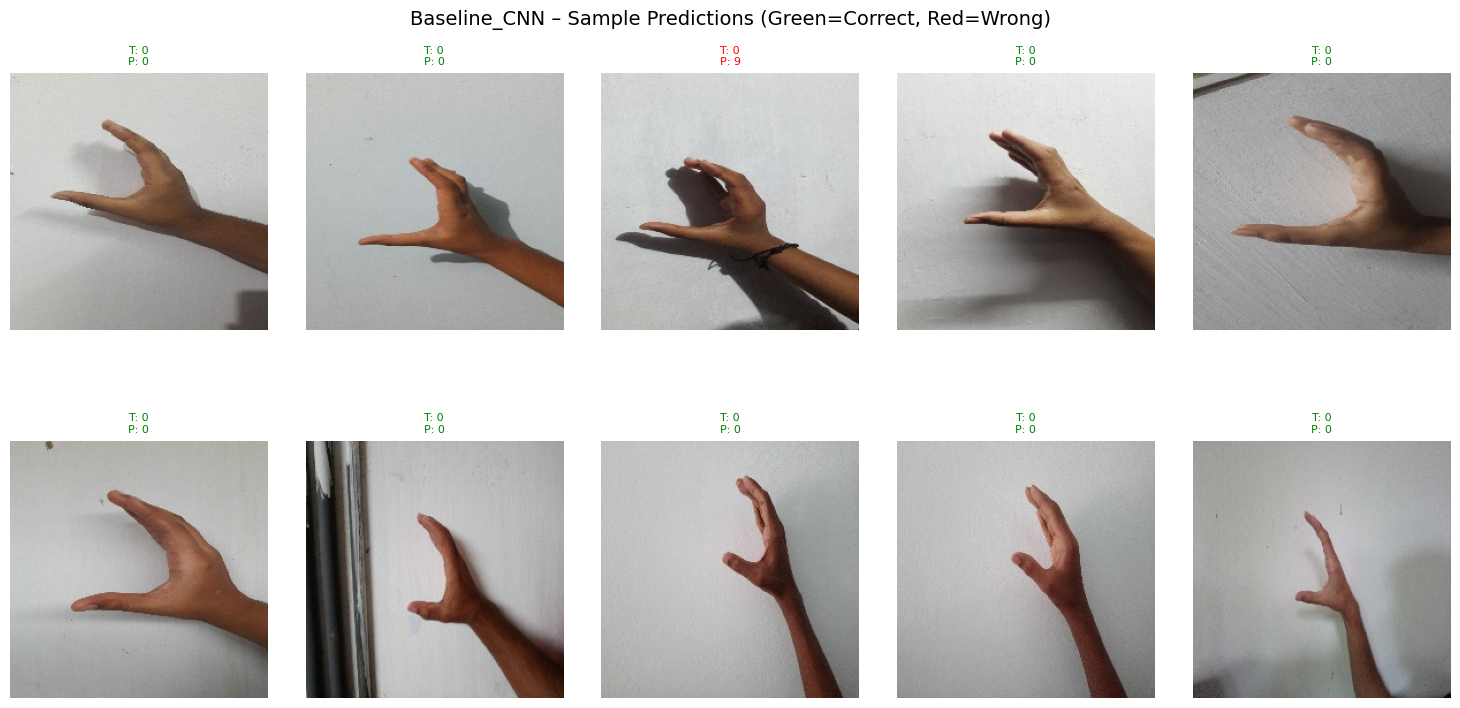

In [ ]:
show_predictions(
    baseline_model,
    test_gen
)

## Deeper Architecture with Regularization Layer:

### Deeper Model Architecture

In [ ]:
def build_deeper_model(num_classes, input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 2
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 3
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Classifier
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ], name='Deeper_CNN')

    return model

In [ ]:
deeper_model = build_deeper_model(NUM_CLASSES)
deeper_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,252,582 (4.78 MB)

 Trainable params: 1,250,790 (4.77 MB)

 Non-trainable params: 1,792 (7.00 KB)

### Training Deeper Model

In [ ]:
early_stop2 = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

checkpoint2 = ModelCheckpoint(
    filepath='deeper_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

start_time = time.time()

In [ ]:
deeper_history = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop2, reduce_lr2, checkpoint2]
)

deeper_train_time = time.time() - start_time
print(f"\nDeeper model training time: {deeper_train_time:.1f} seconds")

Epoch 1/30


2026-05-07 09:39:55.990667: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 09:39:56.189412: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 09:39:58.038859: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 09:39:58.215283: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 09:40:02.117079: E external/local_xla/xla/stream_

120/236 ━━━━━━━━━━━━━━━━━━━━ 46s 398ms/step - accuracy: 0.0310 - loss: 3.8168

2026-05-07 09:41:11.115286: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 09:41:11.307239: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 09:41:12.471891: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 09:41:12.641468: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 09:41:14.586522: E external/local_xla/xla/stream_

236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.0314 - loss: 3.7563
Epoch 1: val_loss improved from inf to 3.78229, saving model to deeper_best_model.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 168s 552ms/step - accuracy: 0.0314 - loss: 3.7560 - val_accuracy: 0.0289 - val_loss: 3.7823 - learning_rate: 0.0010
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.0400 - loss: 3.6377
Epoch 2: val_loss improved from 3.78229 to 3.70054, saving model to deeper_best_model.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 102s 431ms/step - accuracy: 0.0400 - loss: 3.6377 - val_accuracy: 0.0275 - val_loss: 3.7005 - learning_rate: 0.0010
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.0533 - loss: 3.6063
Epoch 3: val_loss did not improve from 3.70054
236/236 ━━━━━━━━━━━━━━━━━━━━ 99s 420ms/step - accuracy: 0.0533 - loss: 3.6062 - val_accuracy: 0.0476 - val_loss: 3.9565 - learning_rate: 0.0010
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.0615 - loss: 3.482

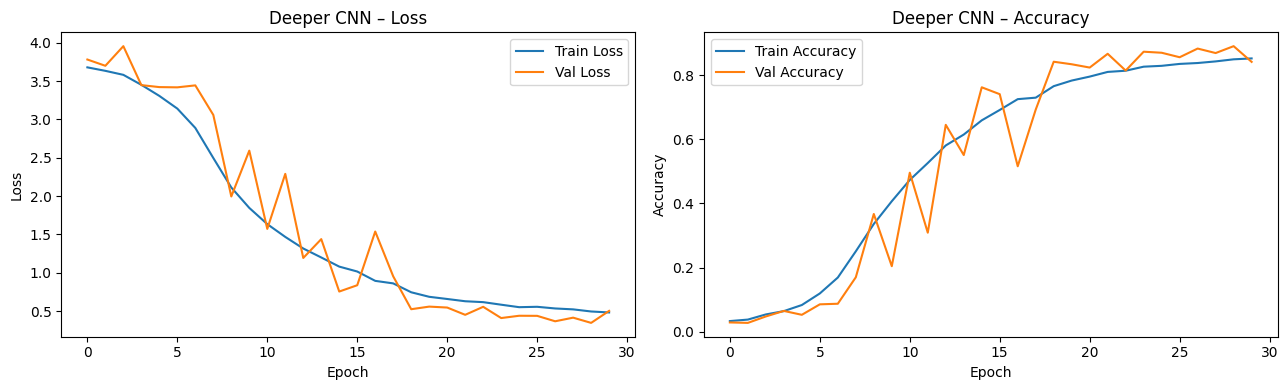

In [ ]:
plot_history(
    deeper_history,
    title='Deeper CNN'
)

### Evaluating Deeper Model


Deeper CNN – Test Loss: 0.3283 | Test Accuracy: 0.9038

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.97      0.88        29
           1       0.96      0.87      0.91        30
          10       0.88      0.97      0.92        30
          11       0.96      0.90      0.93        30
          12       0.96      0.86      0.91        29
          13       0.90      0.97      0.93        29
          14       0.77      0.89      0.83        27
          15       0.95      0.67      0.78        30
          16       0.88      1.00      0.94        30
          17       1.00      0.97      0.98        29
          18       0.87      0.90      0.89        30
          19       0.77      0.80      0.79        30
           2       1.00      0.97      0.98        30
          20       0.93      0.97      0.95        29
          21       0.84      0.93      0.89        29
          22       0.80      0.93      0.86        30
 

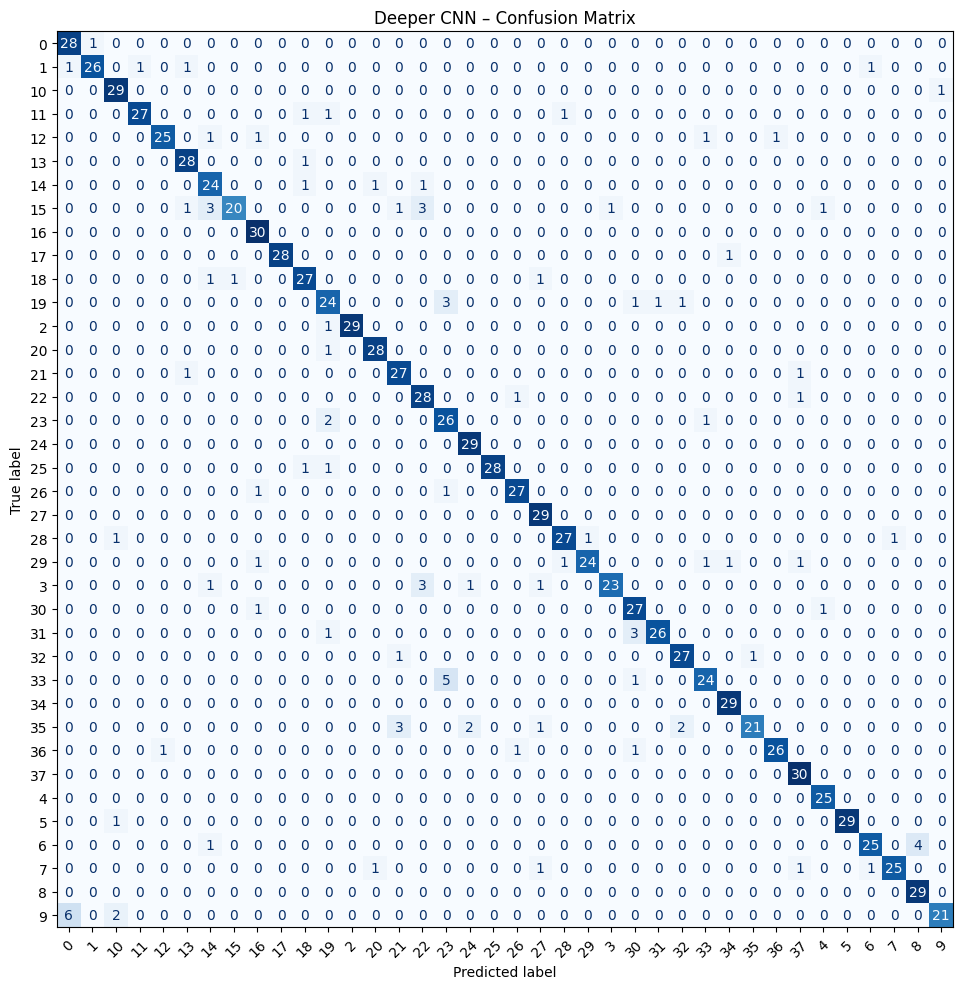

In [ ]:
deeper_pred, deeper_true, deeper_acc = evaluate_model(
    deeper_model,
    test_gen,
    'Deeper CNN'
)

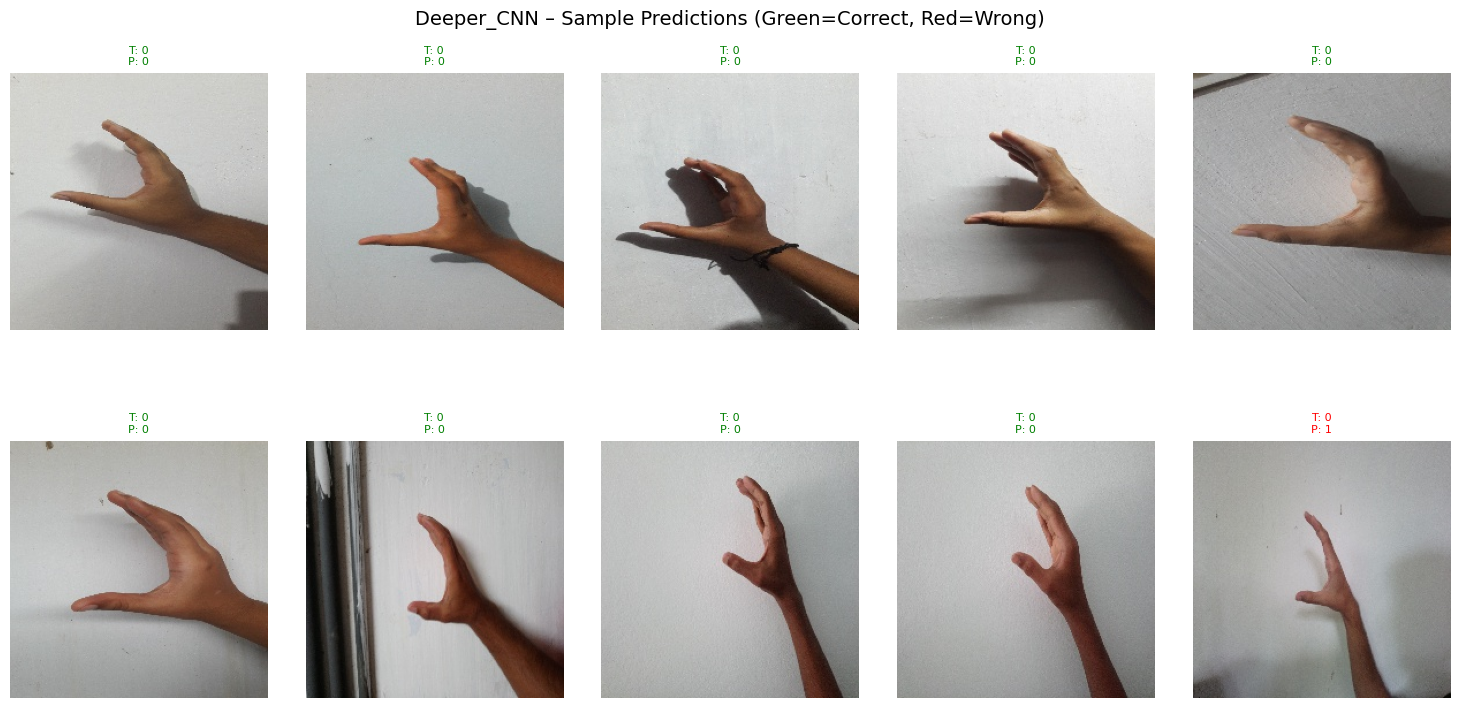

In [ ]:
show_predictions(
    deeper_model,
    test_gen
)

## Experimentation and Comparative Analysis:

### Baseline vs Deeper Model Performance

Baseline CNN  – Test Accuracy: 0.8381
Deeper CNN    – Test Accuracy: 0.9038


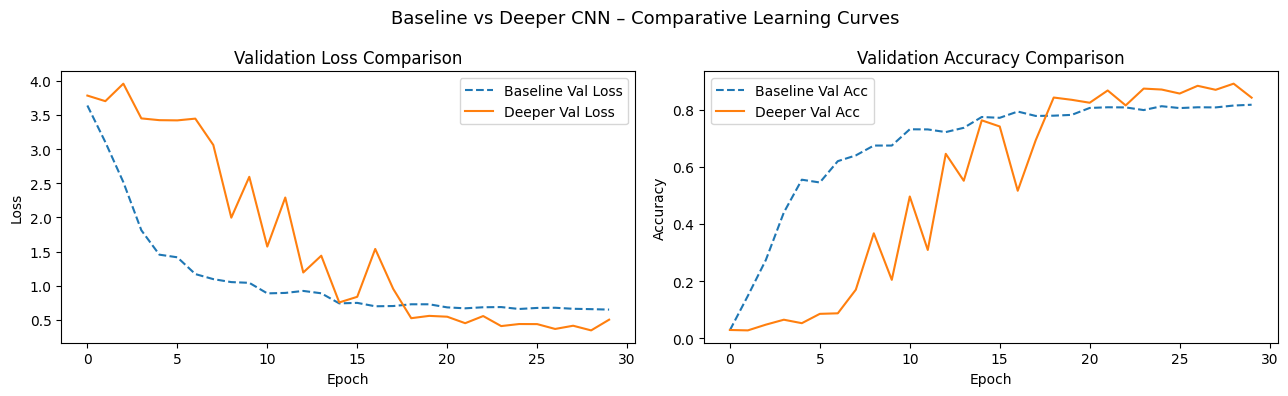

In [ ]:
print(f"Baseline CNN  – Test Accuracy: {baseline_acc:.4f}")
print(f"Deeper CNN    – Test Accuracy: {deeper_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(baseline_history.history['val_loss'], label='Baseline Val Loss', linestyle='--')
axes[0].plot(deeper_history.history['val_loss'],   label='Deeper Val Loss')
axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(baseline_history.history['val_accuracy'], label='Baseline Val Acc', linestyle='--')
axes[1].plot(deeper_history.history['val_accuracy'],   label='Deeper Val Acc')
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Baseline vs Deeper CNN – Comparative Learning Curves', fontsize=13)
plt.tight_layout()
plt.show()

### Computational Efficiency

Baseline CNN – Parameters: 25,827,238 | Training Time: 2717.7s
Deeper CNN   – Parameters: 1,252,582   | Training Time: 3127.0s


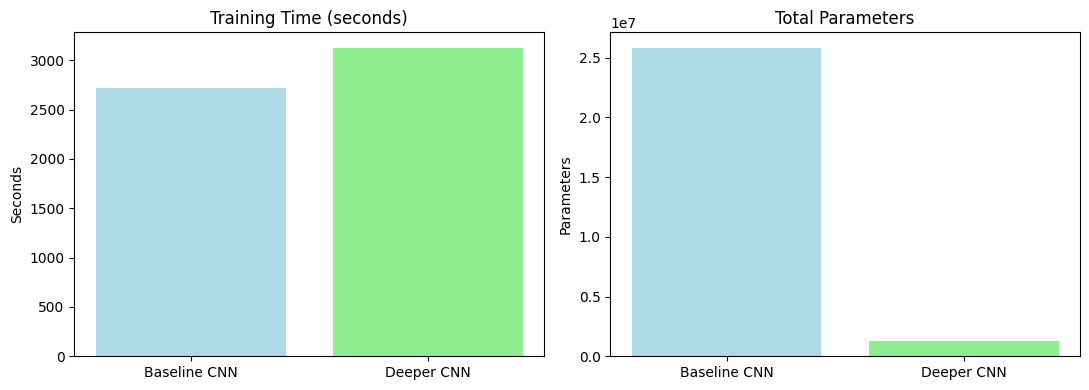

In [ ]:
baseline_params = baseline_model.count_params()
deeper_params   = deeper_model.count_params()

print(f"Baseline CNN – Parameters: {baseline_params:,} | Training Time: {baseline_train_time:.1f}s")
print(f"Deeper CNN   – Parameters: {deeper_params:,}   | Training Time: {deeper_train_time:.1f}s")

labels  = ['Baseline CNN', 'Deeper CNN']
times   = [baseline_train_time, deeper_train_time]
params  = [baseline_params, deeper_params]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(labels, times, color=['lightblue', 'lightgreen'])
axes[0].set_title('Training Time (seconds)')
axes[0].set_ylabel('Seconds')

axes[1].bar(labels, params, color=['lightblue', 'lightgreen'])
axes[1].set_title('Total Parameters')
axes[1].set_ylabel('Parameters')

plt.tight_layout()
plt.show()

### Optimizer Analysis: SGD vs Adam

In [ ]:
# SGD variant
model_sgd = build_deeper_model(NUM_CLASSES)

model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_sgd = model_sgd.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)],
    verbose=1
)

print("SGD training done.")

Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 117s 457ms/step - accuracy: 0.0255 - loss: 3.7654 - val_accuracy: 0.0280 - val_loss: 3.6574
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 106s 449ms/step - accuracy: 0.0406 - loss: 3.6413 - val_accuracy: 0.0285 - val_loss: 3.6470
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 104s 438ms/step - accuracy: 0.0379 - loss: 3.6332 - val_accuracy: 0.0247 - val_loss: 3.6393
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 106s 447ms/step - accuracy: 0.0439 - loss: 3.6265 - val_accuracy: 0.0322 - val_loss: 3.6339
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 105s 443ms/step - accuracy: 0.0425 - loss: 3.6129 - val_accuracy: 0.0350 - val_loss: 3.6393
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 104s 441ms/step - accuracy: 0.0454 - loss: 3.5814 - val_accuracy: 0.0261 - val_loss: 3.8387
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 105s 444ms/step - accuracy: 0.0502 - loss: 3.5130 - val_accuracy: 0.0266 - val_loss: 4.7214
Epoch 8/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 103s 436ms/step - accuracy: 0.0514 -

In [ ]:
# Adam variant
model_adam = build_deeper_model(NUM_CLASSES)

model_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_adam = model_adam.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)],
    verbose=1
)

print("Adam training done.")

Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 123s 474ms/step - accuracy: 0.0318 - loss: 3.7522 - val_accuracy: 0.0266 - val_loss: 3.6943
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 104s 438ms/step - accuracy: 0.0374 - loss: 3.6375 - val_accuracy: 0.0299 - val_loss: 3.7423
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 102s 431ms/step - accuracy: 0.0499 - loss: 3.5757 - val_accuracy: 0.0340 - val_loss: 3.7713
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 105s 444ms/step - accuracy: 0.0590 - loss: 3.4560 - val_accuracy: 0.0695 - val_loss: 3.3968
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 104s 442ms/step - accuracy: 0.0801 - loss: 3.3178 - val_accuracy: 0.0700 - val_loss: 3.3135
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 102s 431ms/step - accuracy: 0.1041 - loss: 3.1631 - val_accuracy: 0.1353 - val_loss: 3.0796
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 104s 439ms/step - accuracy: 0.1314 - loss: 3.0277 - val_accuracy: 0.1255 - val_loss: 2.8907
Epoch 8/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 104s 440ms/step - accuracy: 0.1634 -

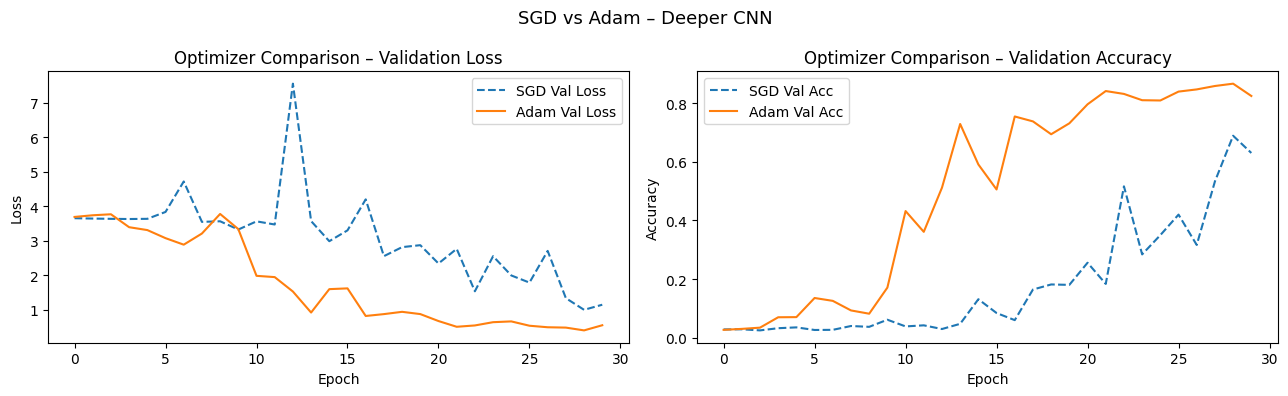

SGD  – Test Accuracy: 0.7095
Adam – Test Accuracy: 0.8849


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_sgd.history['val_loss'],  label='SGD Val Loss',  linestyle='--')
axes[0].plot(history_adam.history['val_loss'], label='Adam Val Loss')
axes[0].set_title('Optimizer Comparison – Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_sgd.history['val_accuracy'],  label='SGD Val Acc',  linestyle='--')
axes[1].plot(history_adam.history['val_accuracy'], label='Adam Val Acc')
axes[1].set_title('Optimizer Comparison – Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('SGD vs Adam – Deeper CNN', fontsize=13)
plt.tight_layout()
plt.show()

sgd_loss,  sgd_acc  = model_sgd.evaluate(test_gen, verbose=0)
adam_loss, adam_acc = model_adam.evaluate(test_gen, verbose=0)
print(f"SGD  – Test Accuracy: {sgd_acc:.4f}")
print(f"Adam – Test Accuracy: {adam_acc:.4f}")

### Ablation Study

In [ ]:
def build_no_dropout_model(num_classes, input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='No_Dropout_CNN')

    return model

In [ ]:
model_no_drop = build_no_dropout_model(NUM_CLASSES)

model_no_drop.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history_no_drop = model_no_drop.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)],
    verbose=1
)
print("No-Dropout model training done.")

Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 114s 450ms/step - accuracy: 0.0331 - loss: 3.6799 - val_accuracy: 0.0308 - val_loss: 3.8558
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 101s 425ms/step - accuracy: 0.0492 - loss: 3.6074 - val_accuracy: 0.0345 - val_loss: 3.6534
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 101s 426ms/step - accuracy: 0.0671 - loss: 3.4618 - val_accuracy: 0.0387 - val_loss: 3.9310
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 102s 431ms/step - accuracy: 0.1258 - loss: 3.1220 - val_accuracy: 0.0392 - val_loss: 3.8911
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 102s 430ms/step - accuracy: 0.2041 - loss: 2.7142 - val_accuracy: 0.1423 - val_loss: 3.1686
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 101s 429ms/step - accuracy: 0.3575 - loss: 2.0594 - val_accuracy: 0.0975 - val_loss: 3.9740
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 102s 430ms/step - accuracy: 0.5262 - loss: 1.5345 - val_accuracy: 0.1544 - val_loss: 3.2750
Epoch 8/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 102s 429ms/step - accuracy: 0.6249 -

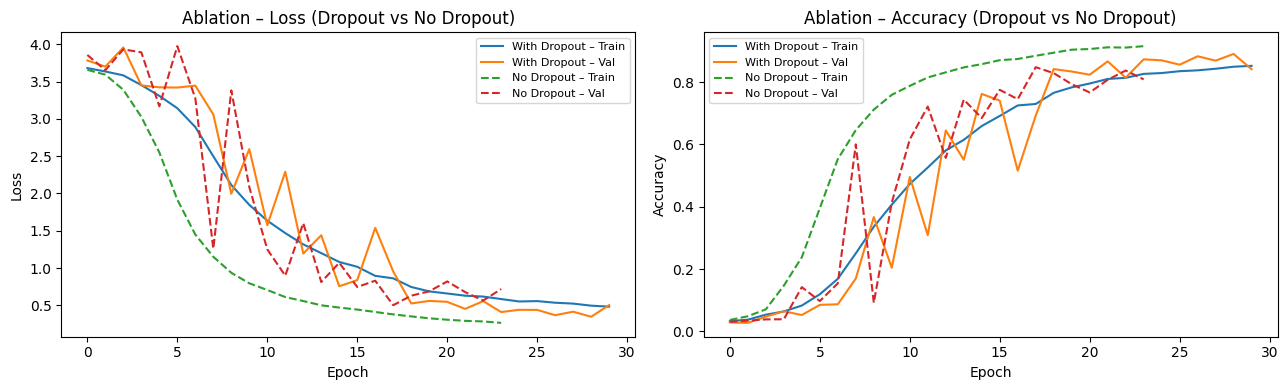

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(deeper_history.history['train_loss'] if 'train_loss' in deeper_history.history
             else deeper_history.history['loss'], label='With Dropout – Train')
axes[0].plot(deeper_history.history['val_loss'],      label='With Dropout – Val')
axes[0].plot(history_no_drop.history['loss'],         label='No Dropout – Train', linestyle='--')
axes[0].plot(history_no_drop.history['val_loss'],     label='No Dropout – Val',   linestyle='--')
axes[0].set_title('Ablation – Loss (Dropout vs No Dropout)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)

axes[1].plot(deeper_history.history['accuracy'],     label='With Dropout – Train')
axes[1].plot(deeper_history.history['val_accuracy'], label='With Dropout – Val')
axes[1].plot(history_no_drop.history['accuracy'],     label='No Dropout – Train', linestyle='--')
axes[1].plot(history_no_drop.history['val_accuracy'], label='No Dropout – Val',   linestyle='--')
axes[1].set_title('Ablation – Accuracy (Dropout vs No Dropout)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
nd_loss, nd_acc = model_no_drop.evaluate(test_gen, verbose=0)
print(f"With Dropout – Test Accuracy: {deeper_acc:.4f}")
print(f"No Dropout   – Test Accuracy: {nd_acc:.4f}")

With Dropout – Test Accuracy: 0.9038
No Dropout   – Test Accuracy: 0.8570


### Challenges and Observations


# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

## Loading and Adapting a Pre-Trained Model

In [ ]:
TL_IMG_SIZE = (224, 224)

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.12,
    brightness_range=[0.75, 1.25],
    shear_range=6,
    horizontal_flip=False,
    fill_mode='nearest',
)

tl_val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

tl_train_gen = tl_train_datagen.flow_from_directory(
    train_dir,
    target_size=TL_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

tl_val_gen = tl_val_test_datagen.flow_from_directory(
    val_dir,
    target_size=TL_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

tl_test_gen = tl_val_test_datagen.flow_from_directory(
    test_dir,
    target_size=TL_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 7536 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
Found 1112 images belonging to 38 classes.


In [ ]:
# Load pre-trained MobileNetV2 without the top classification layer
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all convolutional base layers for feature extraction
base_model.trainable = False

# Add custom classification head
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
tl_model = keras.Model(
    inputs,
    outputs,
    name='MobileNetV2_TL'
)

tl_model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
tl_model.summary()

Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,623,718 (10.01 MB)

 Trainable params: 365,734 (1.40 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Model Training and Fine-Tuning

### Feature Extraction (Frozen Base)

In [ ]:
early_stop_tl = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=15,
    callbacks=[early_stop_tl]
)
print("Phase 1 (Feature Extraction) complete.")

Epoch 1/15


2026-05-07 13:05:29.610701: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 13:05:29.750598: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 76/236 ━━━━━━━━━━━━━━━━━━━━ 58s 365ms/step - accuracy: 0.0546 - loss: 3.7209

2026-05-07 13:06:09.288113: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 13:06:09.425339: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


236/236 ━━━━━━━━━━━━━━━━━━━━ 125s 447ms/step - accuracy: 0.1048 - loss: 3.3801 - val_accuracy: 0.5075 - val_loss: 1.7917
Epoch 2/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 89s 378ms/step - accuracy: 0.3730 - loss: 2.0241 - val_accuracy: 0.5686 - val_loss: 1.3635
Epoch 3/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 89s 378ms/step - accuracy: 0.4639 - loss: 1.6347 - val_accuracy: 0.6241 - val_loss: 1.2064
Epoch 4/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 90s 379ms/step - accuracy: 0.5384 - loss: 1.4140 - val_accuracy: 0.6339 - val_loss: 1.1378
Epoch 5/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 91s 385ms/step - accuracy: 0.5644 - loss: 1.3174 - val_accuracy: 0.6399 - val_loss: 1.0860
Epoch 6/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 89s 379ms/step - accuracy: 0.5993 - loss: 1.2084 - val_accuracy: 0.6511 - val_loss: 1.0446
Epoch 7/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 89s 379ms/step - accuracy: 0.6159 - loss: 1.1578 - val_accuracy: 0.6726 - val_loss: 0.9866
Epoch 8/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 88s 375ms/step - accuracy: 0.6392 - loss: 1.0971 - va

### Fine-Tuning (Unfreeze Last 30 Layers)

In [ ]:
# Unfreeze the top layers of the base model
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a lower learning rate
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=15,
    callbacks=[early_stop_ft]
)
print("Phase 2 (Fine-Tuning) complete.")

Epoch 1/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 117s 427ms/step - accuracy: 0.4852 - loss: 1.7353 - val_accuracy: 0.6964 - val_loss: 1.0133
Epoch 2/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 89s 376ms/step - accuracy: 0.6057 - loss: 1.2279 - val_accuracy: 0.7029 - val_loss: 0.9477
Epoch 3/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 88s 375ms/step - accuracy: 0.6681 - loss: 1.0160 - val_accuracy: 0.7169 - val_loss: 0.9129
Epoch 4/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 89s 376ms/step - accuracy: 0.6814 - loss: 0.9540 - val_accuracy: 0.7379 - val_loss: 0.8417
Epoch 5/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 88s 374ms/step - accuracy: 0.7011 - loss: 0.8911 - val_accuracy: 0.7407 - val_loss: 0.8425
Epoch 6/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 89s 377ms/step - accuracy: 0.7265 - loss: 0.8206 - val_accuracy: 0.7514 - val_loss: 0.7877
Epoch 7/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 87s 369ms/step - accuracy: 0.7413 - loss: 0.7715 - val_accuracy: 0.7505 - val_loss: 0.7871
Epoch 8/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 89s 378ms/step - accuracy: 0.7348 - loss: 

### Transfer Learning - Training Curves

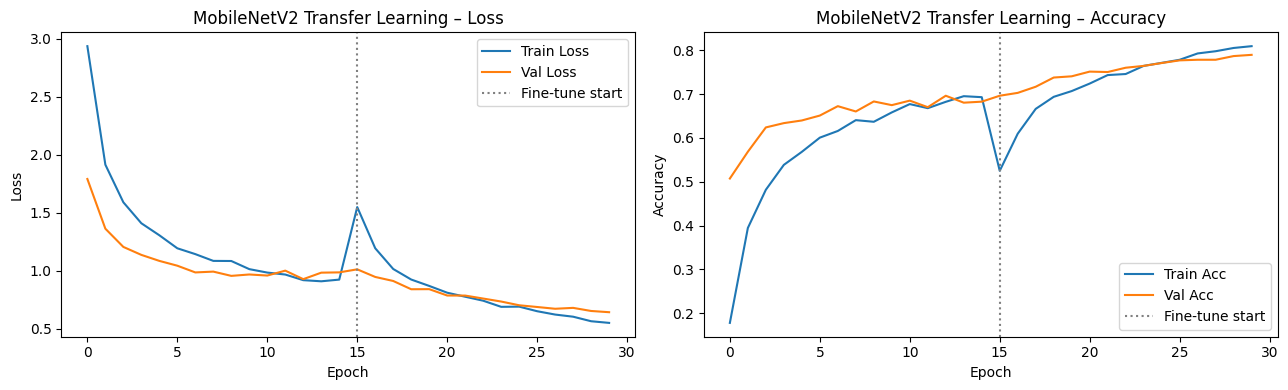

In [ ]:
# Combine both phases for a full training history view
def merge_history(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

combined = merge_history(history_tl_phase1, history_tl_phase2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(combined['loss'],     label='Train Loss')
axes[0].plot(combined['val_loss'], label='Val Loss')
phase1_len = len(history_tl_phase1.history['loss'])
axes[0].axvline(x=phase1_len, color='grey', linestyle=':', label='Fine-tune start')
axes[0].set_title('MobileNetV2 Transfer Learning – Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(combined['accuracy'],     label='Train Acc')
axes[1].plot(combined['val_accuracy'], label='Val Acc')
axes[1].axvline(x=phase1_len, color='grey', linestyle=':', label='Fine-tune start')
axes[1].set_title('MobileNetV2 Transfer Learning – Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## Model Evaluation and Prediction

2026-05-07 13:52:19.981871: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 13:52:20.119611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



MobileNetV2 Transfer Learning – Test Loss: 0.5735 | Test Accuracy: 0.8031

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.90      0.83        29
           1       0.82      0.90      0.86        30
          10       0.85      0.97      0.91        30
          11       1.00      0.90      0.95        30
          12       0.96      0.83      0.89        29
          13       0.71      0.76      0.73        29
          14       0.54      0.70      0.61        27
          15       0.79      0.50      0.61        30
          16       1.00      0.83      0.91        30
          17       0.85      0.79      0.82        29
          18       0.85      0.57      0.68        30
          19       0.74      0.67      0.70        30
           2       0.79      0.63      0.70        30
          20       0.79      0.93      0.86        29
          21       0.96      0.76      0.85        29
          22       0.57      0.90   

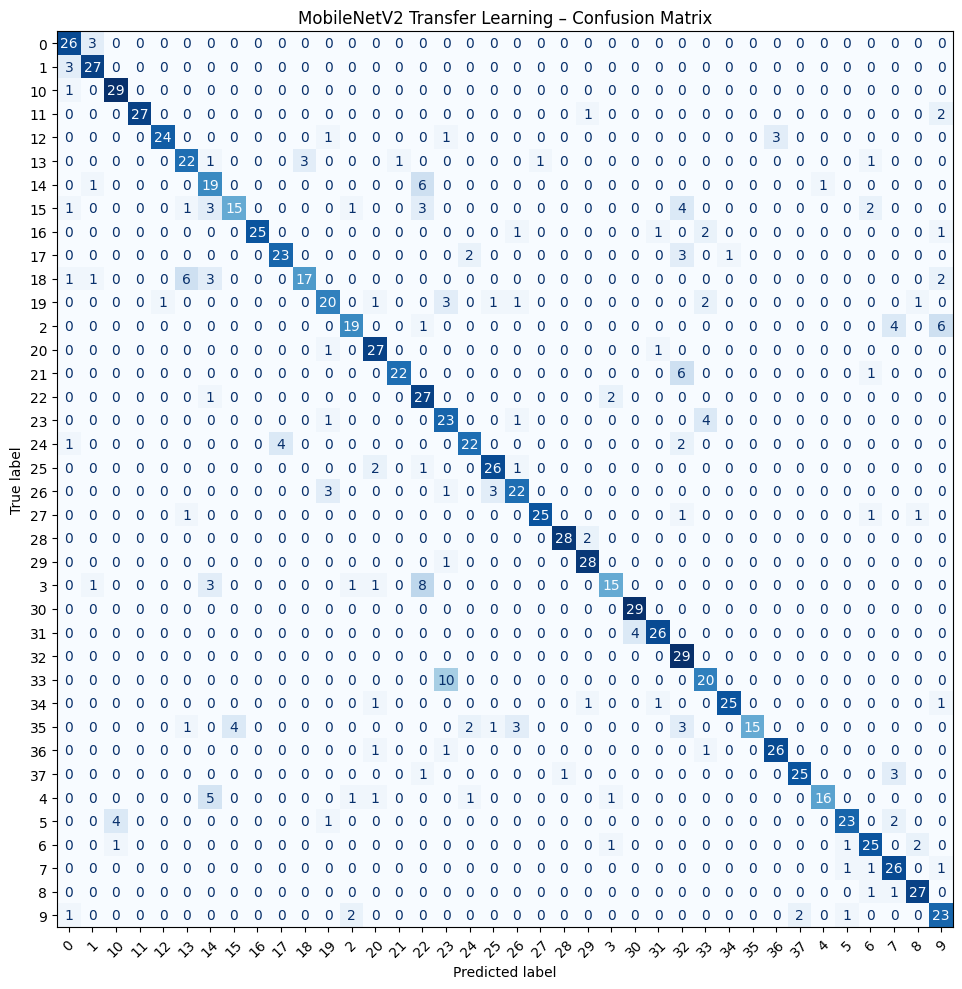

In [ ]:
tl_pred, tl_true, tl_acc = evaluate_model(
    tl_model,
    tl_test_gen,
    'MobileNetV2 Transfer Learning'
)

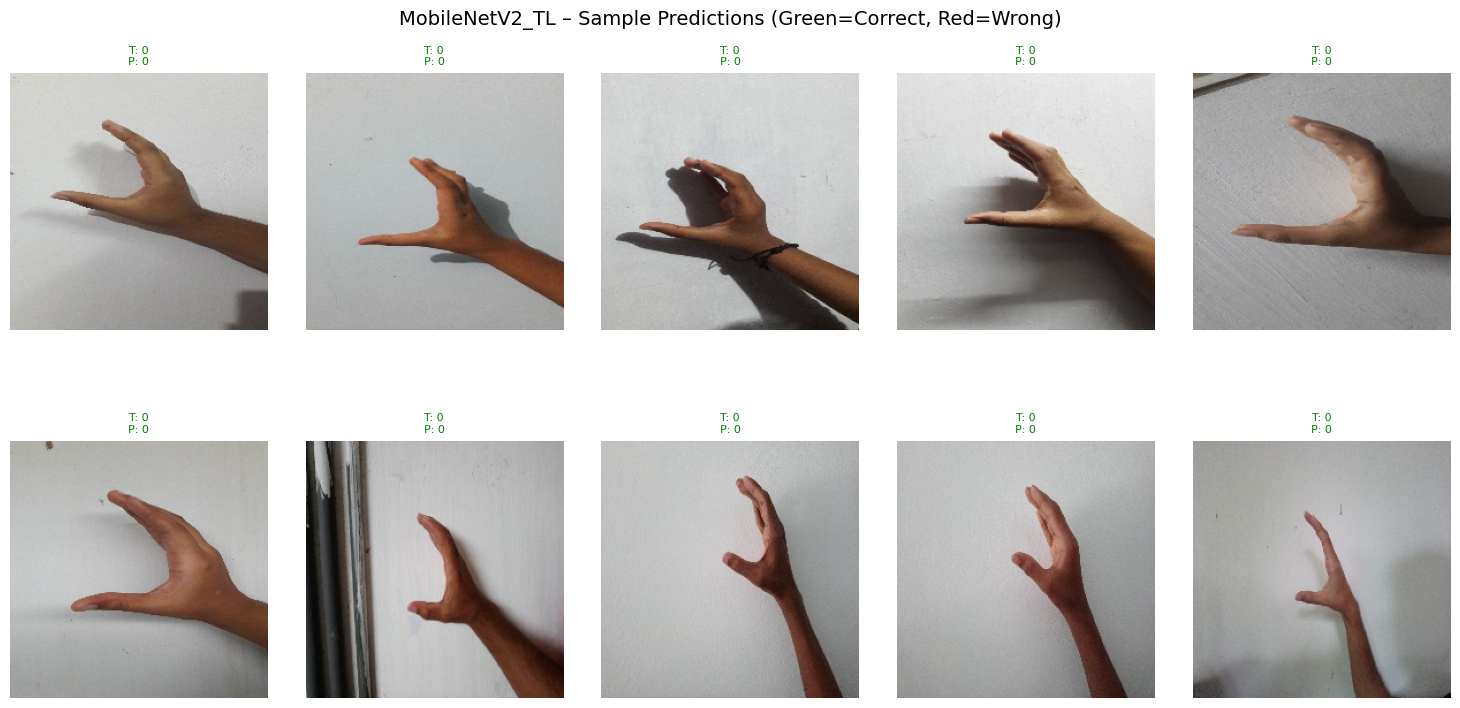

In [ ]:
show_predictions(tl_model, tl_test_gen)

### Final Comparision - All Models

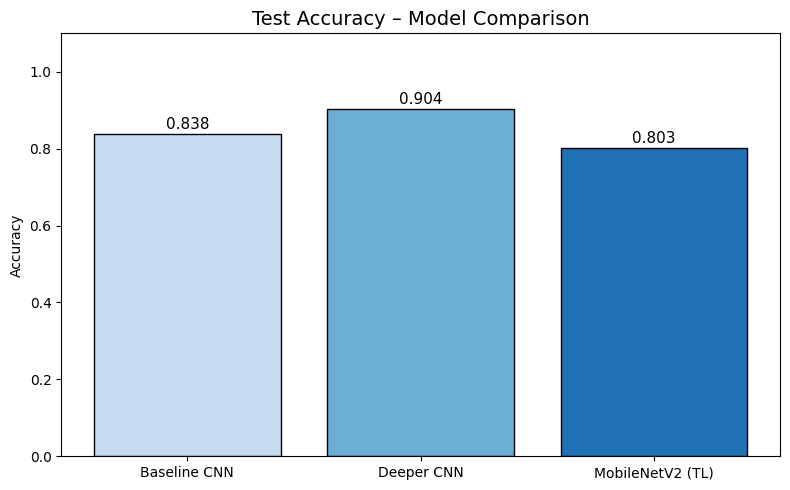


Summary:
  Baseline CNN                  : 0.8381
  Deeper CNN                    : 0.9038
  MobileNetV2 (TL)              : 0.8031


In [ ]:
model_names = ['Baseline CNN', 'Deeper CNN', 'MobileNetV2 (TL)']
accuracies  = [baseline_acc, deeper_acc, tl_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=['#c6dbef', '#6baed6', '#2171b5'], edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=11)
plt.title('Test Accuracy – Model Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

print("\nSummary:")
for name, acc in zip(model_names, accuracies):
    print(f"  {name:30s}: {acc:.4f}")